In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

import xgboost as xgb

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import RandomizedSearchCV

# Data Loading


In [2]:
df = pd.read_csv('../data/Loan_data.csv')

In [3]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [4]:
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


# Preprocessing

#### Détection des valeurs manquantes:

In [5]:
nans = df.isna().sum(axis=0)
print(nans.sum())

0


Pas de valeurs manquantes, pas besoin de les traiter.

#### Traitement des dates

In [6]:
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])
df['ApplicationYear'] = df['ApplicationDate'].dt.year
df['ApplicationMonth'] = df['ApplicationDate'].dt.month
df['ApplicationDay'] = df['ApplicationDate'].dt.day
df = df.drop('ApplicationDate', axis=1)

### Séparation des variables numériques et catégorielles

In [7]:
numerical_vars = df.select_dtypes(include=['number']).columns.tolist()
categorical_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_vars_count = {col: df[col].nunique() for col in categorical_vars}

In [8]:
print('Variables numériques:', numerical_vars)
print('Variables catégorielles:', categorical_vars_count)

Variables numériques: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore', 'ApplicationYear', 'ApplicationMonth', 'ApplicationDay']
Variables catégorielles: {'EmploymentStatus': 3, 'EducationLevel': 5, 'MaritalStatus': 4, 'HomeOwnershipStatus': 4, 'LoanPurpose': 5}


#### Encodage des variables catégorielles (one-hot encoding)

In [9]:
drop = 'first'
encoder = OneHotEncoder(sparse_output=False, drop=drop)
encoded = encoder.fit_transform(df[list(categorical_vars_count.keys())])
encoded_categorical_vars = encoder.get_feature_names_out(list(categorical_vars_count.keys()))
encoded_df = pd.DataFrame(encoded, columns=encoded_categorical_vars)

In [10]:
encoded_df = df[numerical_vars].join(encoded_df)

In [11]:
encoded_df.head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,45,39948,617,22,13152,48,2,183,0.354418,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,38,39709,628,15,26045,48,1,496,0.087827,5,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,47,40724,570,26,17627,36,2,902,0.137414,2,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,58,69084,545,34,37898,96,1,755,0.267587,2,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,37,103264,594,17,9184,36,1,274,0.320535,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Analyse exploratoire des données

#### Matrice de corrélation des variables numériques

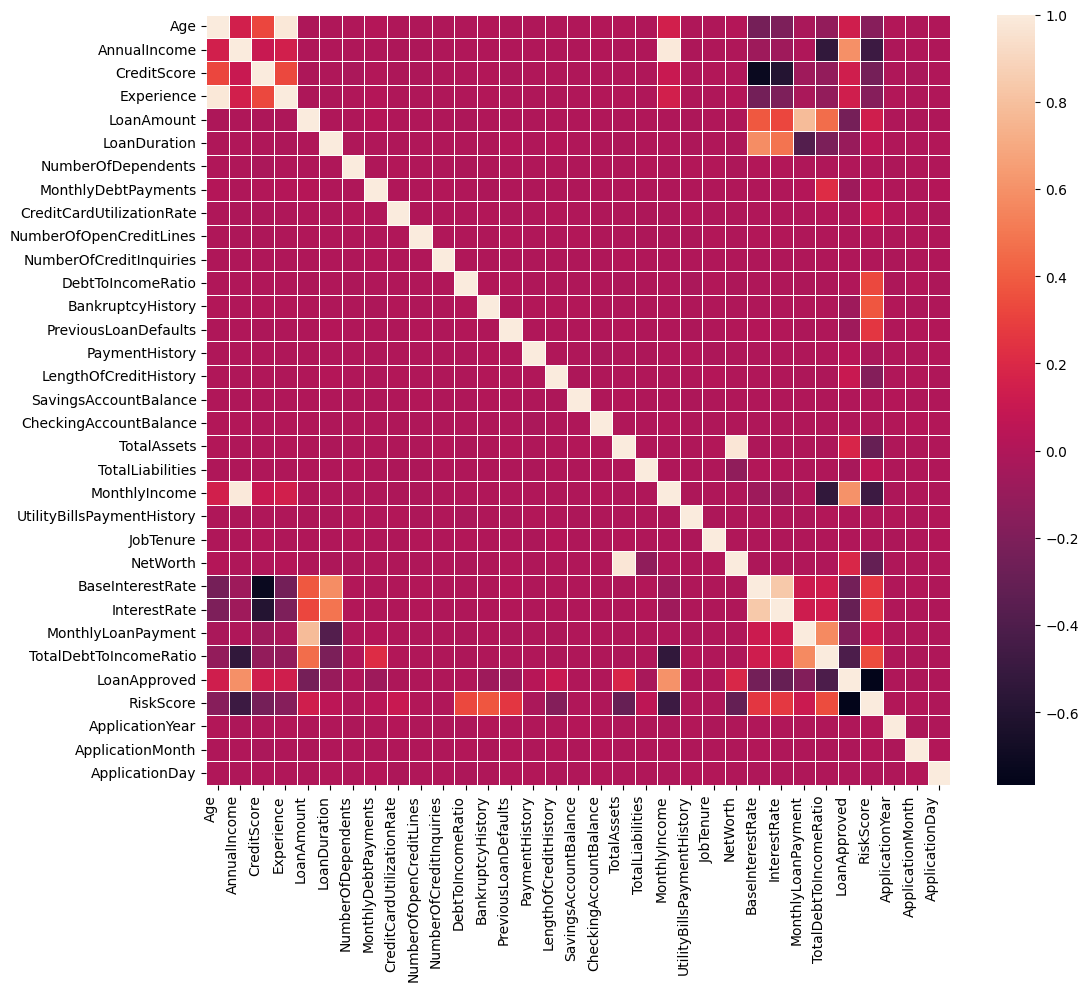

In [12]:
plt.figure(figsize=(12, 10))

sns.heatmap(encoded_df[numerical_vars].corr(), 
            linewidths=0.5, 
            xticklabels=True, 
            yticklabels=True)

plt.xticks(rotation=90, ha='right') 
plt.yticks(rotation=0)              

plt.show()


#### Matrice de corrélations des variables catégorielles (après encodage)

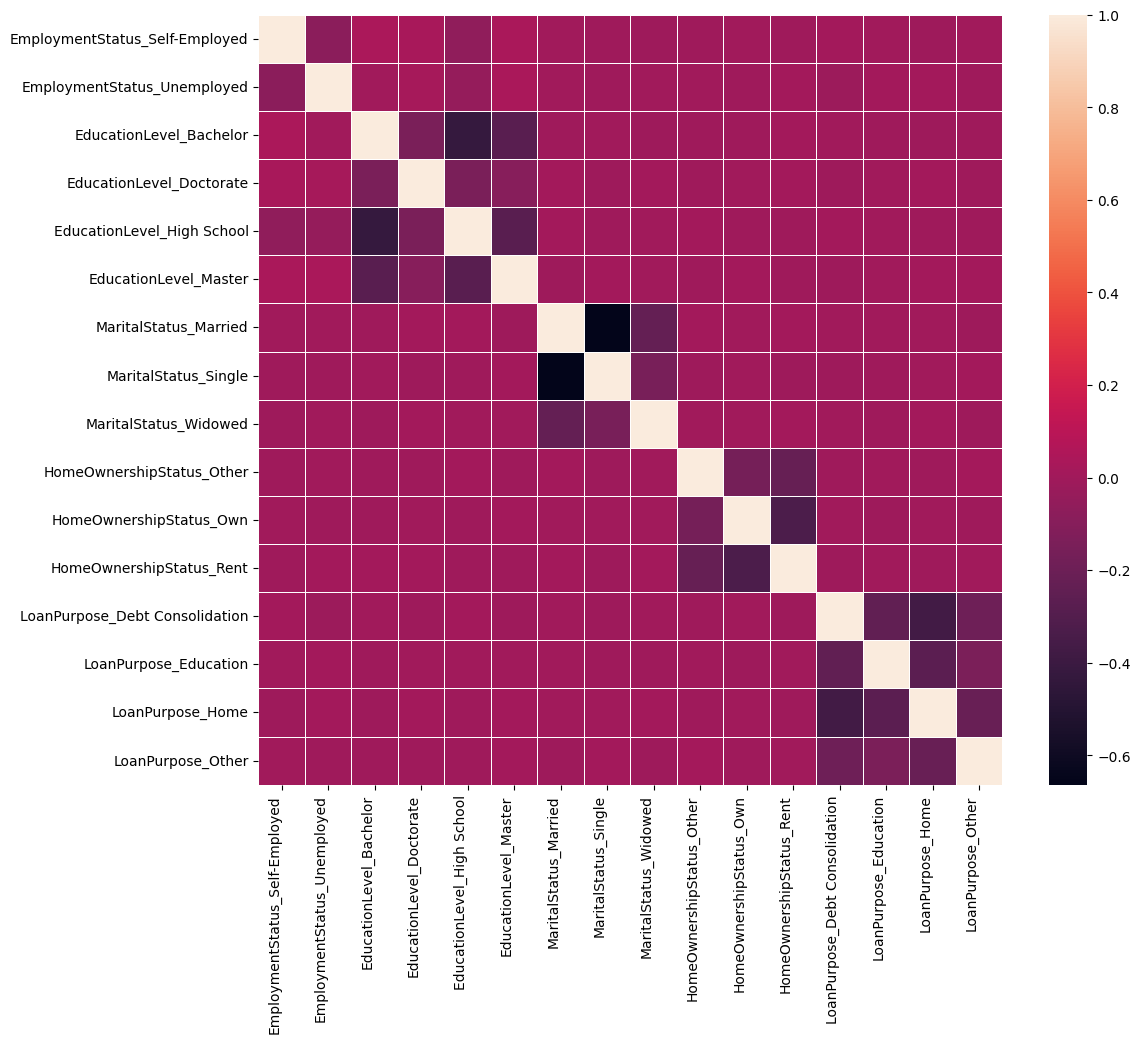

In [13]:

plt.figure(figsize=(12, 10))

sns.heatmap(encoded_df[encoded_categorical_vars].corr(), 
            linewidths=0.5, 
            xticklabels=True, 
            yticklabels=True)

plt.xticks(rotation=90, ha='right') 
plt.yticks(rotation=0)              

plt.show()


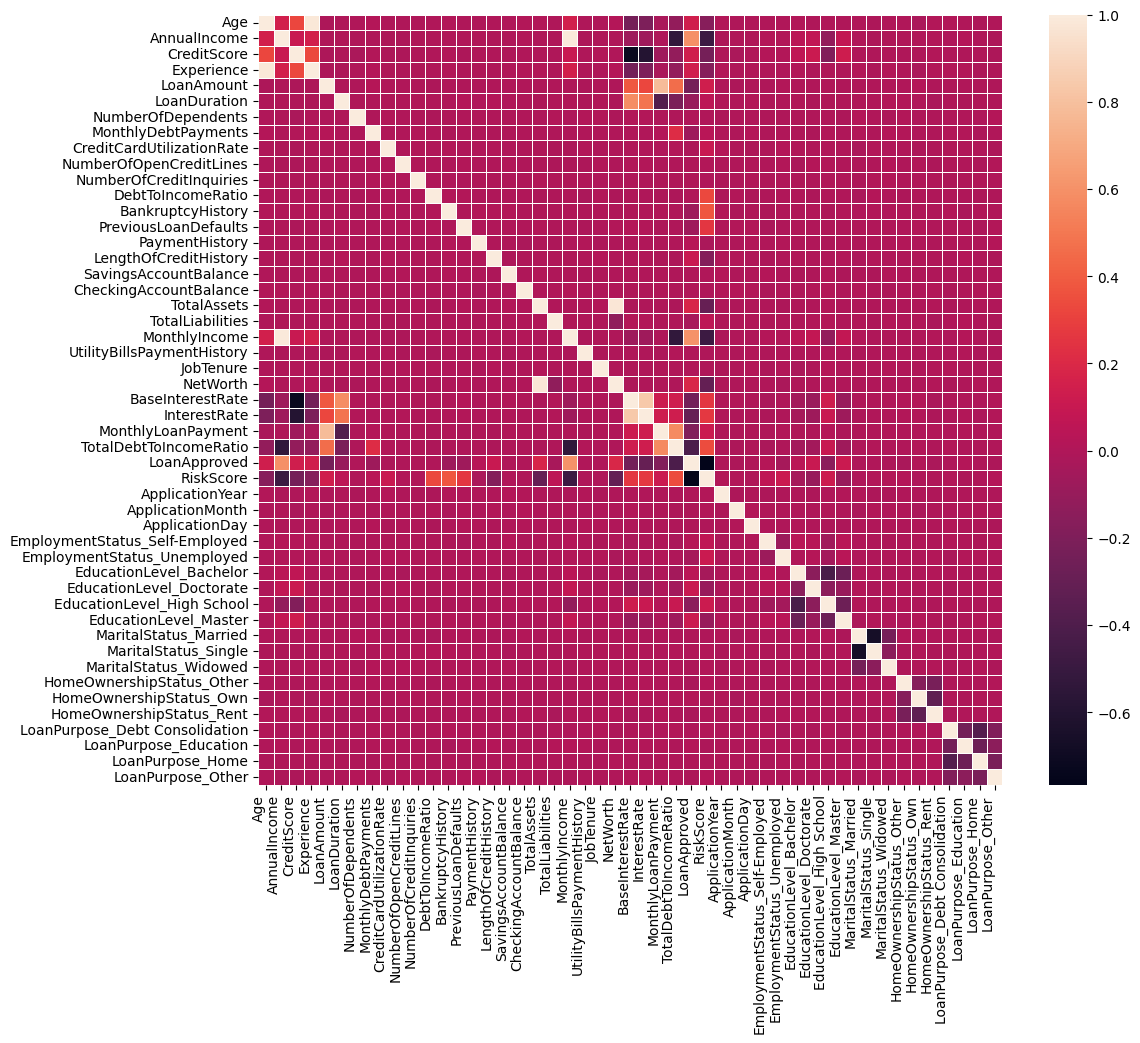

In [14]:

plt.figure(figsize=(12, 10))

sns.heatmap(encoded_df.corr(), 
            linewidths=0.5, 
            xticklabels=True, 
            yticklabels=True)

plt.xticks(rotation=90, ha='right') 
plt.yticks(rotation=0)              

plt.show()

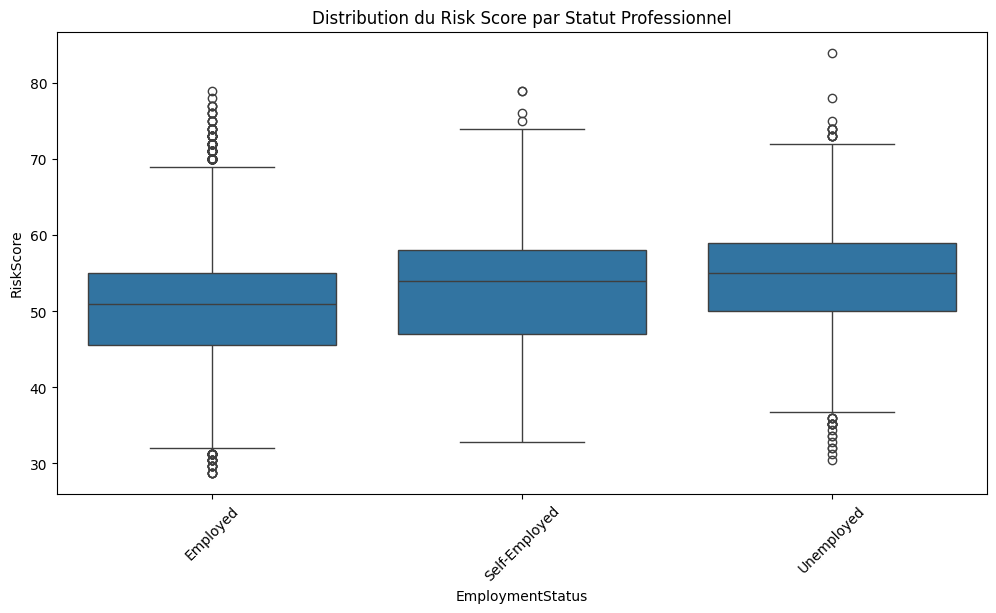

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='EmploymentStatus', y='RiskScore', data=df)
plt.xticks(rotation=45)
plt.title('Distribution du Risk Score par Statut Professionnel')
plt.show()

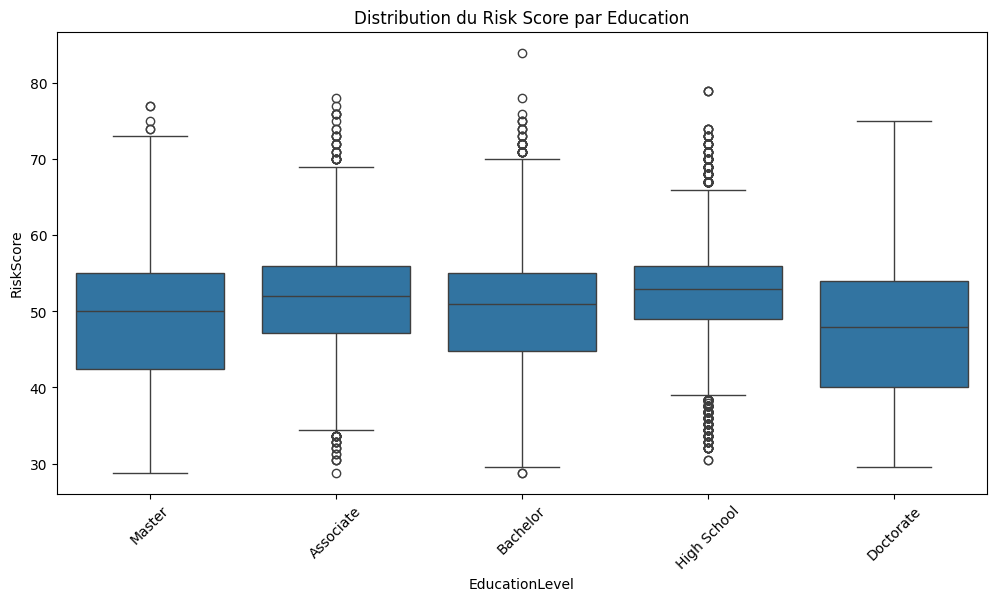

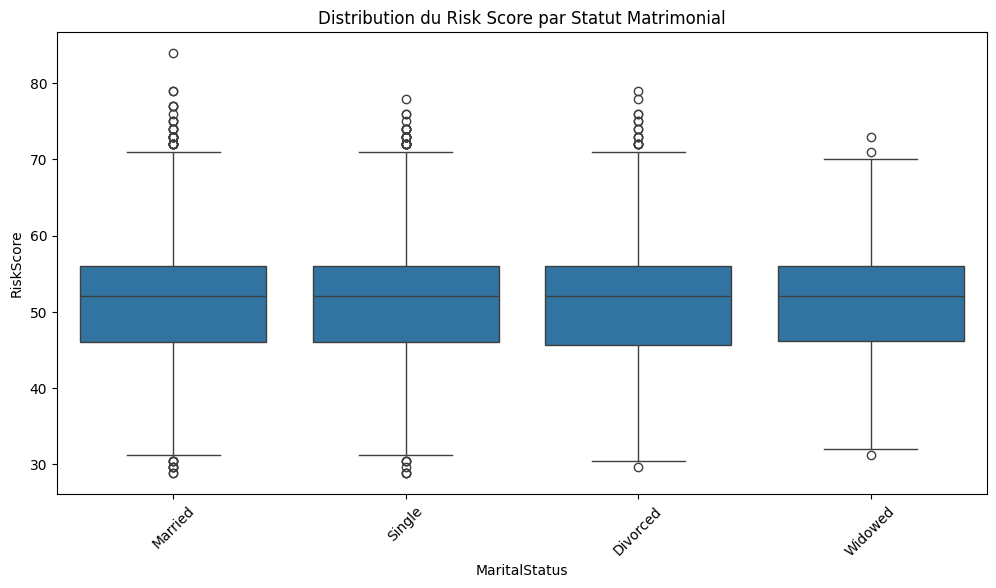

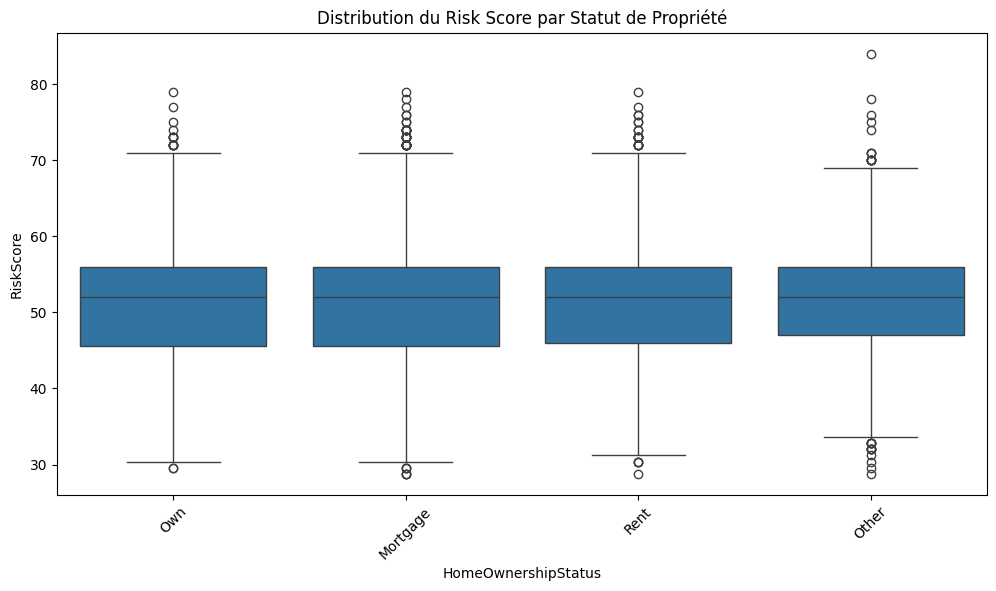

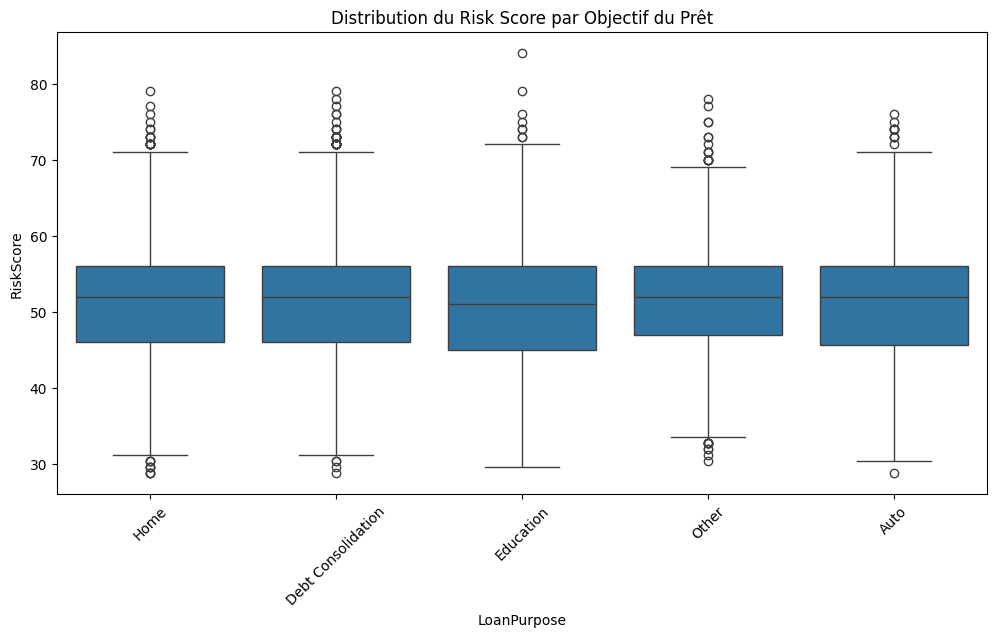

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='EducationLevel', y='RiskScore', data=df)
plt.xticks(rotation=45)
plt.title('Distribution du Risk Score par Education')
plt.show()
plt.figure(figsize=(12, 6))
sns.boxplot(x='MaritalStatus', y='RiskScore', data=df)
plt.xticks(rotation=45)
plt.title('Distribution du Risk Score par Statut Matrimonial')
plt.show()
plt.figure(figsize=(12, 6))
sns.boxplot(x='HomeOwnershipStatus', y='RiskScore', data=df)
plt.xticks(rotation=45)
plt.title('Distribution du Risk Score par Statut de Propriété')
plt.show()
plt.figure(figsize=(12, 6))
sns.boxplot(x='LoanPurpose', y='RiskScore', data=df)
plt.xticks(rotation=45)
plt.title('Distribution du Risk Score par Objectif du Prêt')
plt.show()


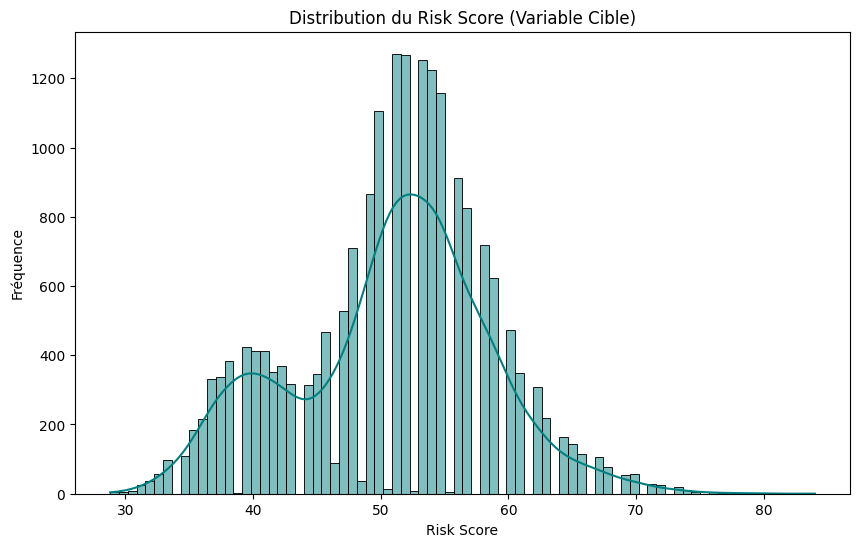

In [17]:

plt.figure(figsize=(10, 6))
sns.histplot(df['RiskScore'], kde=True, bins=80, color='teal')
plt.title('Distribution du Risk Score (Variable Cible)')
plt.xlabel('Risk Score')
plt.ylabel('Fréquence')
plt.show()

# Feature engineering


In [18]:
#  Transformations Logarithmiques pour réduire l'asymétrie 
cols_to_log = ['AnnualIncome', 'LoanAmount', 'NetWorth', 'TotalAssets', 'TotalLiabilities']
for col in cols_to_log:
    # On vérifie qu'il n'y a pas de valeurs négatives problématiques
    if (df[col] >= 0).all():
        df[f'Log_{col}'] = np.log1p(df[col])
        


In [19]:

# Tranches d'âge
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [20]:
# Total Cash 
df['Total_Cash'] = df['SavingsAccountBalance'] + df['CheckingAccountBalance']

# Ratio de couverture du prêt par le cash
df['Cash_to_Loan_Ratio'] = df['Total_Cash'] / (df['LoanAmount'] + 1)

# Ratio Épargne / Revenu Annuel 
df['Savings_to_Income'] = df['Total_Cash'] / (df['AnnualIncome'] + 1)


#  Ratio d'endettement global
df['Global_Debt_Ratio'] = df['TotalLiabilities'] / (df['TotalAssets'] + 1)

# Poids du prêt demandé par rapport au revenu annuel
df['Loan_to_Income'] = df['LoanAmount'] / (df['AnnualIncome'] + 1)


# Revenu mensuel - Dettes mensuelles actuelles - Futur paiement du prêt
df['Free_Cash_Flow'] = df['MonthlyIncome'] - df['MonthlyDebtPayments'] - df['MonthlyLoanPayment']

# Reste à vivre par personne
df['Income_Per_Capita'] = df['Free_Cash_Flow'] / (df['NumberOfDependents'] + 1)

# Spread de taux 
# Si c'est élevé, l'analyste humain ou le système précédent a déjà vu un risque.
df['Interest_Spread'] = df['InterestRate'] - df['BaseInterestRate']

On refait le one-hot encodding

In [21]:
numerical_vars = df.select_dtypes(include=['number']).columns.tolist()

categorical_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_vars_count = {col: df[col].nunique() for col in categorical_vars}
print('Variables numériques:', numerical_vars)
print('Variables catégorielles:', categorical_vars_count)

Variables numériques: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore', 'ApplicationYear', 'ApplicationMonth', 'ApplicationDay', 'Log_AnnualIncome', 'Log_LoanAmount', 'Log_NetWorth', 'Log_TotalAssets', 'Log_TotalLiabilities', 'Total_Cash', 'Cash_to_Loan_Ratio', 'Savings_to_Income', 'Global_Debt_Ratio', 'Loan_to_Income', 'Free_Cash_Flow', 'Income_Per_Capita', 'Interest_Spread']
Variables catégorielles: {'EmploymentStatus': 3, 'EducationLevel': 5, 'MaritalS

In [22]:
drop = 'first'
encoder = OneHotEncoder(sparse_output=False, drop=drop)
encoded = encoder.fit_transform(df[list(categorical_vars_count.keys())])
encoded_categorical_vars = encoder.get_feature_names_out(list(categorical_vars_count.keys()))
encoded_df = pd.DataFrame(encoded, columns=encoded_categorical_vars)
encoded_df = df[numerical_vars].join(encoded_df)

In [23]:
encoded_df.head()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,AgeGroup_26-35,AgeGroup_36-45,AgeGroup_46-55,AgeGroup_56-65,AgeGroup_65+,AgeGroup_nan
0,45,39948,617,22,13152,48,2,183,0.354418,1,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,38,39709,628,15,26045,48,1,496,0.087827,5,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,47,40724,570,26,17627,36,2,902,0.137414,2,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,58,69084,545,34,37898,96,1,755,0.267587,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,37,103264,594,17,9184,36,1,274,0.320535,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


# Entraînement des modèles


### Division train test

In [24]:

non_train_col = ['LoanApproved', 'RiskScore']

X_train, X_test, y_train, y_test = train_test_split(encoded_df.drop(columns=non_train_col), encoded_df['RiskScore'], test_size=0.2, random_state=1)

### Baseline: Modèle trivial et régression linéaire

 "Modèle" aléatoire

In [25]:
y_pred = pd.DataFrame(data=np.random.normal(df['RiskScore'].mean(), df['RiskScore'].std(), size=y_test.shape), index=y_test.index)

In [26]:
print(f"RMSE final sur Test : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² final sur Test   : {r2_score(y_test, y_pred):.4f}")

RMSE final sur Test : 10.9185
R² final sur Test   : -0.9861


Régression linéaire

In [27]:
from sklearn.linear_model import LinearRegression

# on scale pour la régression linéaire
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


linear_regressor = LinearRegression().fit(X_train_scaled, y_train)

y_pred = linear_regressor.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métriques sur X_test ---")
print(f"RMSE : {rmse:.4f}") 
print(f"MAE  : {mae:.4f}")   
print(f"R²   : {r2:.4f}")    


--- Métriques sur X_test ---
RMSE : 3.3482
MAE  : 2.6836
R²   : 0.8132


### CART

In [28]:


cart_regressor = DecisionTreeRegressor(random_state=1)

param_grid = {
    'max_depth': [3, 5, 8, 12],            
    'min_samples_split': [2, 10, 20],      # Limiter les divisions trop fines
    'min_samples_leaf': [1, 5, 10, 20],     # évite les valeurs extrêmes isolées
    'max_features': [None, 'sqrt', 'log2'],
}


In [29]:

cv = KFold(n_splits=5, shuffle=True, random_state=1)


grid_search_cart = GridSearchCV(
    estimator=cart_regressor,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search_cart.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search_cart.best_params_}")
print(f"Meilleur RMSE (CV) : {-grid_search_cart.best_score_:.4f}")


Fitting 5 folds for each of 144 candidates, totalling 720 fits

c:\Users\cleme\OneDrive\Documents\payment-default-forcasting\.venv\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Meilleurs paramètres : {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 20, 'min_samples_split': 2}
Meilleur RMSE (CV) : 3.6767


In [30]:

best_cart = grid_search_cart.best_estimator_
y_pred = best_cart.predict(X_test)

print(f"RMSE final sur Test : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² final sur Test   : {r2_score(y_test, y_pred):.4f}")

RMSE final sur Test : 3.5590
R² final sur Test   : 0.7890


### Random Forest

In [31]:

rf_regressor = RandomForestRegressor(random_state=1,n_jobs=-1)




In [32]:
param_grid = {
    'max_depth': [3, 5, 8, 12],
    'min_samples_split': [2, 10, 20],   
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': [1/3, 'sqrt', 'log2']
}



In [33]:

cv = KFold(n_splits=5, shuffle=True, random_state=1)

grid_search_rf = GridSearchCV(
    estimator=rf_regressor,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=1,
    verbose=2
)

grid_search_rf.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search_rf.best_params_}")
print(f"Meilleur RMSE (CV) : {-grid_search_rf.best_score_:.4f}")


Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=2; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=2; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=2; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=2; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=2; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=10; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=10; total time=   0.3s
[CV] END max_depth=3, max_features=0.3333333333333333, min_samples_leaf=1, min_samples_split=10; total time=   0.3s
[CV] END max_d

c:\Users\cleme\OneDrive\Documents\payment-default-forcasting\.venv\Lib\site-packages\numpy\ma\core.py:2896: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,



Meilleurs paramètres : {'max_depth': 12, 'max_features': 0.3333333333333333, 'min_samples_leaf': 1, 'min_samples_split': 2}
Meilleur RMSE (CV) : 3.0070


In [34]:




best_rf = grid_search_rf.best_estimator_
y_pred = best_rf.predict(X_test)

print(f"RMSE final sur Test : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² final sur Test   : {r2_score(y_test, y_pred):.4f}")

RMSE final sur Test : 2.9581
R² final sur Test   : 0.8542


XGBoost

In [35]:


xgb.set_config(verbosity=2)

device = 'cuda'

xgb_regressor = xgb.XGBRegressor(tree_method='hist', device = device)


In [36]:

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 8, 12],
    'n_estimators': [500, 1000],
    "subsample": [0.7, 1.0],        
    "colsample_bytree": [0.7, 1.0],
    
    "min_child_weight": [1, 5, 10], 
    "reg_lambda": [1, 5, 10],    
    "reg_alpha": [0, 0.1, 1.0],     
}




In [37]:

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_regressor,
    param_distributions=param_grid,
    n_iter=40,                       
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1,         
    verbose=2,
    random_state=1
)
random_search_xgb.fit(X_train, y_train)

print(f"\nMeilleurs paramètres : {random_search_xgb.best_params_}")
print(f"Meilleur RMSE (CV) : {-random_search_xgb.best_score_:.4f}")


Fitting 3 folds for each of 40 candidates, totalling 120 fits
[13:46:18] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (10666, 66, 703956).
[13:46:18] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.


c:\Users\cleme\OneDrive\Documents\payment-default-forcasting\.venv\Lib\site-packages\xgboost\core.py:774: UserWarning: [13:46:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=8, min_child_weight=5, n_estimators=1000, reg_alpha=1.0, reg_lambda=1, subsample=0.7; total time=   6.8s
[13:46:25] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (10667, 66, 704022).
[13:46:25] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=8, min_child_weight=5, n_estimators=1000, reg_alpha=1.0, reg_lambda=1, subsample=0.7; total time=   5.9s
[13:46:31] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (10667, 66, 704022).
[13:46:31] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\ellpack_page.cu:167: Ellpack is dense.
[CV] END colsample_bytree=1.0, learning_rate=0.01, max_depth=8, min_child_weight=5, n_estimators=1000, reg_alpha=1.0, reg_lambda=1, subsample=

In [38]:

best_xgb = random_search_xgb.best_estimator_
y_pred = best_xgb.predict(X_test)

print(f"RMSE final sur Test : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R² final sur Test   : {r2_score(y_test, y_pred):.4f}")


RMSE final sur Test : 2.2115
R² final sur Test   : 0.9185


### CAT Boost

In [39]:
# on utilise pas le encoded ici car catboost gère les catégorielles nativement

X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=non_train_col), df['RiskScore'], test_size=0.2, random_state=1)

In [43]:
cat_vars = list(categorical_vars_count.keys())
print(cat_vars)
model = CatBoostRegressor(
    task_type="GPU", devices="0",
    verbose=0,              
    cat_features=cat_vars,
    loss_function='RMSE',   
    thread_count=-1,
    early_stopping_rounds=50,
    random_state=1
)


['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'AgeGroup']


In [41]:

param_grid = {
    'depth': [4, 8,12],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [500, 1000],
    'l2_leaf_reg': [1, 3, 5],
}




In [42]:

# 4. Configurer le GridSearch
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error', 
    cv=3,
    n_jobs=1,
    verbose=2
)

grid_search.fit(X_train, y_train)
print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur RMSE (CV) : {-grid_search.best_score_:.4f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.01; total time=   0.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.01; total time=   0.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.01; total time=   0.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.05; total time=   0.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.05; total time=   0.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.05; total time=   0.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.1; total time=   0.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.1; total time=   0.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=1, learning_rate=0.1; total time=   0.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=3, learning_rate=0.01; total time=   0.0s
[CV] END depth=4, iterations=500, l2_leaf_reg=3, learning_rat

ValueError: 
All the 162 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
54 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\cleme\OneDrive\Documents\payment-default-forcasting\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\cleme\OneDrive\Documents\payment-default-forcasting\.venv\Lib\site-packages\catboost\core.py", line 5873, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\cleme\OneDr

In [ ]:

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métriques sur X_test ---")
print(f"RMSE : {rmse:.4f}") 
print(f"MAE  : {mae:.4f}")   
print(f"R²   : {r2:.4f}")    


--- Métriques sur X_test ---
RMSE : 0.2386
MAE  : 0.1482
R²   : 0.6900
